# Phase 1: Dual-Tiered Photocard Gating Engine
**Objective:** Train and benchmark two lightweight models (Edge and Server) for binary classification (`news_photocard` vs `non_photocard`).

**Research Tracking:** Generates and exports comprehensive performance plots, confusion matrices, and epoch metrics for academic analysis.

In [10]:
!pip install -q timm matplotlib seaborn scikit-learn onnx onnxscript

import os
import time
import json
import requests
import torch
import torch.nn as nn
import torch.optim as optim
import torch.onnx
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import timm

# Metrics and Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
from IPython.display import display, Image, Markdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 12.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 12.2 MB/s eta 0:00:00


### 2.1 Hardware and API Configuration

In [11]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Executing on: {DEVICE}")

STORAGE_UPLOAD_URL = "https://storage.saifullahmnsur.dev/upload"

# Ensure dataset contains folders: 'news_photocard' and 'non_photocard'
DATASET_PATH = "/kaggle/input/datasets/saifullahmnsur/photocard-or-not-dataset/photocard-or-not-dataset"

[*] Executing on: cuda


### 2.2 Storage Hub Upload Helper

In [12]:
def upload_artifact_to_hub(filepath):
    """Pushes artifacts (.pth, .png, .json) to the central storage server."""
    filename = os.path.basename(filepath)
    print(f"[*] Uploading {filename}...")
    try:
        with open(filepath, 'rb') as f:
            files = {'file': (filename, f, 'application/octet-stream')}
            response = requests.post(STORAGE_UPLOAD_URL, files=files)
            
        if response.status_code == 200:
            print(f"  [+] Upload Success!")
        else:
            print(f"  [!] Upload Failed. HTTP {response.status_code}: {response.text}")
    except Exception as e:
        print(f"  [!] Upload Exception: {str(e)}")

### 3.1 Dataset Loading and Transformation

In [13]:
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

try:
    full_dataset = datasets.ImageFolder(root=DATASET_PATH, transform=data_transforms)
    class_names = full_dataset.classes  # Should be ['news_photocard', 'non_photocard']
    
    # 70% Train | 15% Validation | 15% Test
    train_size = int(0.70 * len(full_dataset))
    val_size = int(0.15 * len(full_dataset))
    test_size = len(full_dataset) - train_size - val_size
    
    train_set, val_set, test_set = random_split(
        full_dataset, 
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_set, batch_size=64, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_set, batch_size=64, shuffle=False, num_workers=2)
    
    print(f"[+] Dataset structured successfully.")
    print(f"    Classes detected: {class_names}")
    print(f"    Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")
except Exception as e:
    print(f"[!] Dataset loading error: Ensure DATASET_PATH is correct. Error: {e}")

[+] Dataset structured successfully.
    Classes detected: ['news_photocard', 'non_photocard']
    Train: 2529 | Val: 541 | Test: 543


### 4.1 Evaluation & Plotting Functions
Generates confusion matrices, learning curves, and saves them directly to disk for API upload.

In [14]:
def generate_and_display_plots(train_losses, val_losses, train_accs, val_accs, all_preds, all_labels, alias):
    os.makedirs("/kaggle/working/metrics", exist_ok=True)
    
    # 1. Plot & Display Learning Curves
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss', marker='o')
    plt.plot(val_losses, label='Validation Loss', marker='o')
    plt.title(f'{alias.upper()} - Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Acc', marker='o')
    plt.plot(val_accs, label='Validation Acc', marker='o')
    plt.title(f'{alias.upper()} - Accuracy Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    
    curves_path = f"/kaggle/working/metrics/{alias}_learning_curves.png"
    plt.tight_layout()
    plt.savefig(curves_path)
    plt.show() # Display inline in Kaggle
    plt.close()
    
    # 2. Plot & Display Confusion Matrix (Test Set)
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{alias.upper()} - Test Set Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    
    cm_path = f"/kaggle/working/metrics/{alias}_test_confusion_matrix.png"
    plt.tight_layout()
    plt.savefig(cm_path)
    plt.show() # Display inline in Kaggle
    plt.close()
    
    # 3. Save Classification Report (JSON)
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    report_path = f"/kaggle/working/metrics/{alias}_test_classification_report.json"
    with open(report_path, 'w') as f:
        json.dump(report, f, indent=4)
        
    return curves_path, cm_path, report_path

### 5.1 Training Loop with Metric Tracking

In [19]:
def train_and_benchmark(model_name: str, alias: str, epochs=5):
    print(f"\n{'='*60}")
    print(f"--- Training & Testing Candidate [{alias}]: {model_name} ---")
    print(f"{'='*60}")
    
    model = timm.create_model(model_name, pretrained=True, num_classes=2).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    # --- 1. TRAINING & VALIDATION LOOP ---
    for epoch in range(epochs):
        model.train()
        running_loss, corrects = 0.0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            corrects += torch.sum(preds == labels.data)
            
        epoch_loss = running_loss / len(train_set)
        epoch_acc = (corrects.double() / len(train_set)).item() * 100
        
        model.eval()
        val_loss, val_corrects = 0.0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels.data)
                
        val_epoch_loss = val_loss / len(val_set)
        val_epoch_acc = (val_corrects.double() / len(val_set)).item() * 100
        
        history['train_loss'].append(epoch_loss)
        history['val_loss'].append(val_epoch_loss)
        history['train_acc'].append(epoch_acc)
        history['val_acc'].append(val_epoch_acc)
        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {epoch_acc:.2f}% | Val Acc: {val_epoch_acc:.2f}%")

    # --- 2. COMPREHENSIVE TESTING PHASE (Holdout Set) ---
    print("\n[*] Initiating Testing Phase on Unseen Data...")
    model.eval()
    test_corrects = 0
    all_preds, all_labels = [], []
    
    start_time = time.time()
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            test_corrects += torch.sum(preds == labels.data)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    total_test_time = time.time() - start_time
    test_acc = (test_corrects.double() / len(test_set)).item() * 100
    avg_latency_ms = (total_test_time / len(test_set)) * 1000
    
    # Save PyTorch Model
    model_path = f"/kaggle/working/{alias}_{model_name}.pth"
    torch.save(model.state_dict(), model_path)
    file_size_mb = os.path.getsize(model_path) / (1024 * 1024)

    # --- 3. ONNX EXPORT PIPELINE (FIXED) ---
    print("\n[*] Exporting to ONNX format for Production Inference...")
    onnx_path = f"/kaggle/working/{alias}_{model_name}.onnx"
    
    # Static batch size of 1 for stable export and web inference
    dummy_input = torch.randn(1, 3, 224, 224, device=DEVICE)
    
    try:
        # Removed opset_version to bypass the buggy version_converter
        torch.onnx.export(
            model, 
            dummy_input, 
            onnx_path,
            export_params=True,
            do_constant_folding=True,
            input_names=['input'],
            output_names=['output']
        )
        onnx_size_mb = os.path.getsize(onnx_path) / (1024 * 1024)
        
        # Verification check
        if onnx_size_mb < 2.0:
            print(f"[!] Warning: ONNX file is suspiciously small ({onnx_size_mb:.2f} MB). Export likely failed silently.")
        else:
            print(f"[+] ONNX Export successful! File size: {onnx_size_mb:.2f} MB")
            
    except Exception as e:
        print(f"[!] ONNX Export Failed: {e}")
        onnx_size_mb = 0.0

    # --- 4. DISPLAY FINAL RESEARCH SUMMARY ---
    summary_md = f"""
### 📊 Comprehensive Testing Outcome: `{alias}`
* **Test Accuracy:** `{test_acc:.2f}%`
* **PyTorch Latency:** `{avg_latency_ms:.2f} ms / image`
* **PyTorch Size:** `{file_size_mb:.2f} MB`
* **ONNX Model Size:** `{onnx_size_mb:.2f} MB` (Exported for Web/CPU)
    """
    display(Markdown(summary_md))
    
    # Generate, display, and save plots
    curves_path, cm_path, report_path = generate_and_display_plots(
        history['train_loss'], history['val_loss'], 
        history['train_acc'], history['val_acc'], 
        all_preds, all_labels, alias
    )
    
    # --- 5. UPLOAD ARTIFACTS TO STORAGE HUB ---
    print("\n[*] Pushing Research Artifacts & ONNX Models to Storage Hub...")
    upload_artifact_to_hub(model_path)
    if onnx_size_mb > 0:
        upload_artifact_to_hub(onnx_path)
    upload_artifact_to_hub(curves_path)
    upload_artifact_to_hub(cm_path)
    upload_artifact_to_hub(report_path)

### 6.1 Run Phase 1 Matrices
Executes the training and uploads all data, models, and graphical plots to the server.


--- Training & Testing Candidate [edge_gate]: mobilenetv4_conv_small ---
Epoch 1/5 | Train Acc: 83.43% | Val Acc: 80.59%
Epoch 2/5 | Train Acc: 91.38% | Val Acc: 94.09%
Epoch 3/5 | Train Acc: 94.62% | Val Acc: 95.75%
Epoch 4/5 | Train Acc: 96.28% | Val Acc: 95.75%
Epoch 5/5 | Train Acc: 97.23% | Val Acc: 96.12%

[*] Initiating Testing Phase on Unseen Data...

[*] Exporting to ONNX format for Production Inference...


W0723 17:50:43.010000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0723 17:50:43.012000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0723 17:50:43.014000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0723 17:50:43.016000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[!] Warning: ONNX file is suspiciously small (0.22 MB). Export likely failed silently.



### 📊 Comprehensive Testing Outcome: `edge_gate`
* **Test Accuracy:** `93.92%`
* **PyTorch Latency:** `9.16 ms / image`
* **PyTorch Size:** `9.72 MB`
* **ONNX Model Size:** `0.22 MB` (Exported for Web/CPU)
    

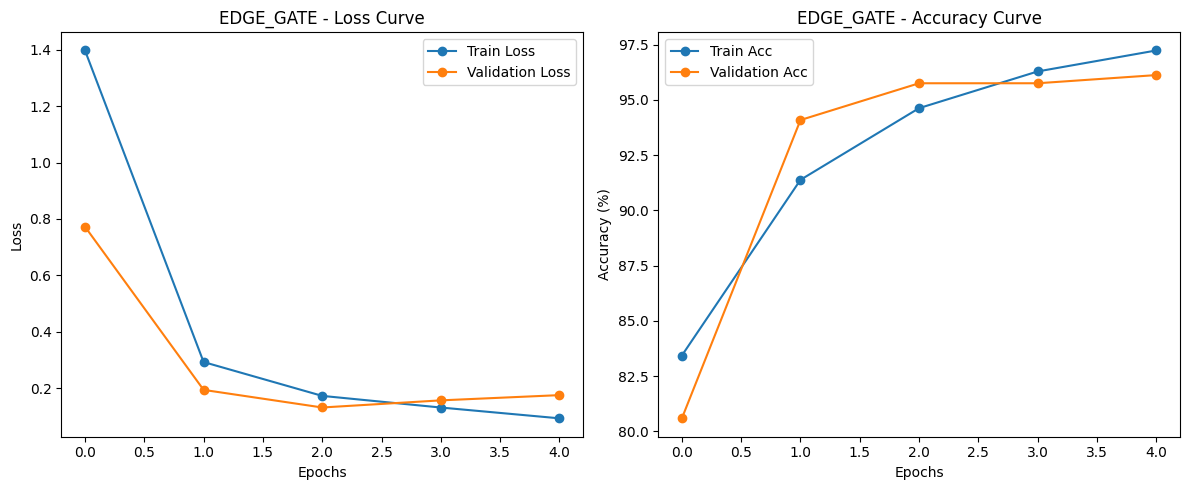

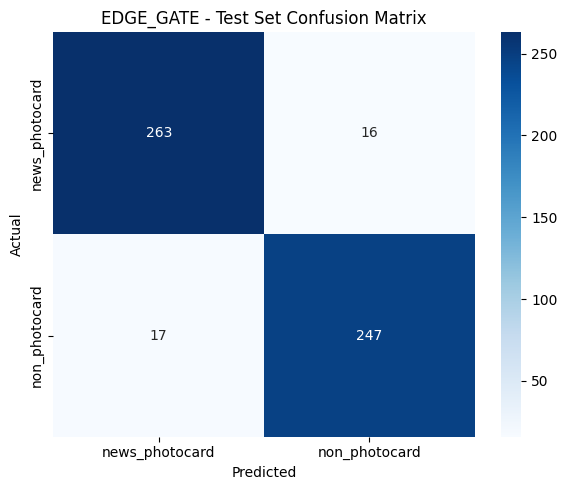


[*] Pushing Research Artifacts & ONNX Models to Storage Hub...
[*] Uploading edge_gate_mobilenetv4_conv_small.pth...
  [+] Upload Success!
[*] Uploading edge_gate_mobilenetv4_conv_small.onnx...
  [+] Upload Success!
[*] Uploading edge_gate_learning_curves.png...
  [+] Upload Success!
[*] Uploading edge_gate_test_confusion_matrix.png...
  [+] Upload Success!
[*] Uploading edge_gate_test_classification_report.json...
  [+] Upload Success!

--- Training & Testing Candidate [server_gate]: efficientnet_b3 ---
Epoch 1/5 | Train Acc: 88.85% | Val Acc: 91.87%
Epoch 2/5 | Train Acc: 96.60% | Val Acc: 96.12%
Epoch 3/5 | Train Acc: 98.89% | Val Acc: 97.04%
Epoch 4/5 | Train Acc: 99.49% | Val Acc: 96.86%
Epoch 5/5 | Train Acc: 99.45% | Val Acc: 96.67%

[*] Initiating Testing Phase on Unseen Data...

[*] Exporting to ONNX format for Production Inference...


W0723 17:53:42.723000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0723 17:53:42.725000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0723 17:53:42.726000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0723 17:53:42.728000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[!] Warning: ONNX file is suspiciously small (0.79 MB). Export likely failed silently.



### 📊 Comprehensive Testing Outcome: `server_gate`
* **Test Accuracy:** `96.32%`
* **PyTorch Latency:** `9.27 ms / image`
* **PyTorch Size:** `41.35 MB`
* **ONNX Model Size:** `0.79 MB` (Exported for Web/CPU)
    

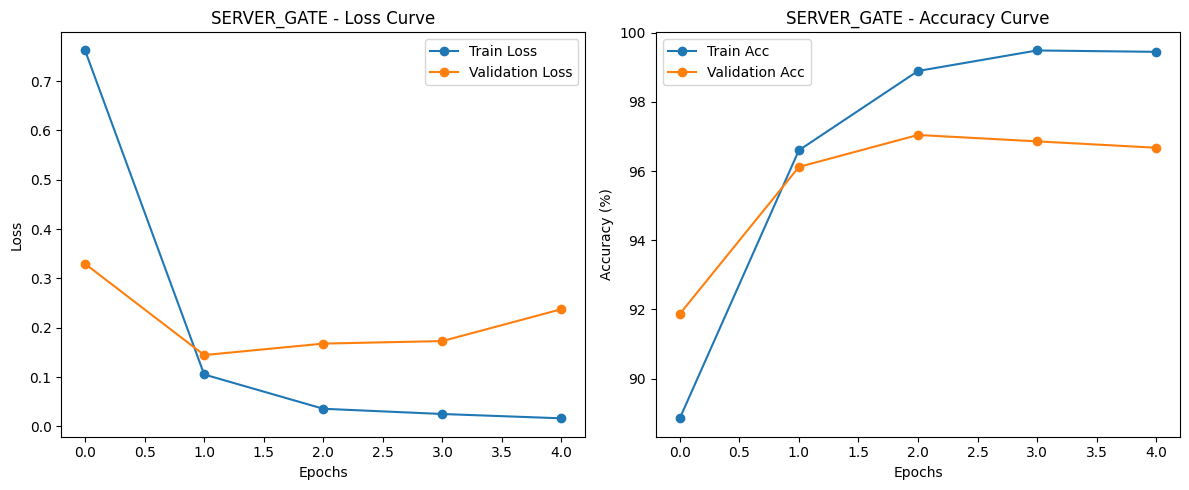

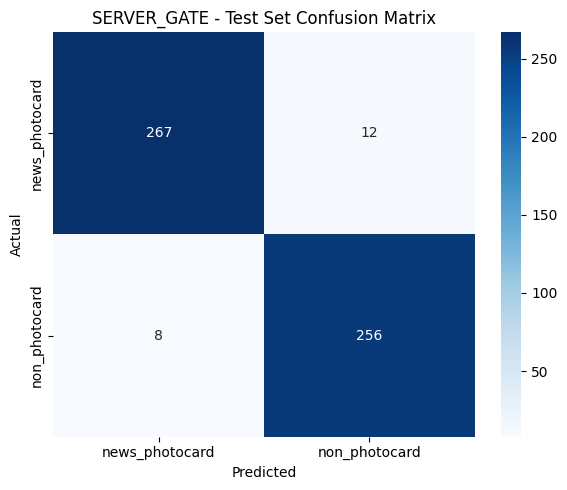


[*] Pushing Research Artifacts & ONNX Models to Storage Hub...
[*] Uploading server_gate_efficientnet_b3.pth...
  [+] Upload Success!
[*] Uploading server_gate_efficientnet_b3.onnx...
  [+] Upload Success!
[*] Uploading server_gate_learning_curves.png...
  [+] Upload Success!
[*] Uploading server_gate_test_confusion_matrix.png...
  [+] Upload Success!
[*] Uploading server_gate_test_classification_report.json...
  [+] Upload Success!


In [20]:
if 'train_loader' in locals():
    # 1. Edge/Client Gate -> MobileNetV4 (Exported for ONNX Web Runtime browser execution)
    # Using 'mobilenetv4_conv_small' which is a standard Timm string for this architecture
    train_and_benchmark(model_name="mobilenetv4_conv_small", alias="edge_gate", epochs=5)
    
    # 2. Server Gate -> EfficientNet-B3 (Exported for optimized FastAPI CPU execution)
    train_and_benchmark(model_name="efficientnet_b3", alias="server_gate", epochs=5)
else:
    print("[!] Execution aborted. Please fix the dataset path.")